In [1]:
import torch
import cv2
import segmentation_models_pytorch as smp

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("ALL GOOD 🔥")


C:\Users\Voona\OneDrive\Desktop\retina-blood-vessel-segmentation\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Torch version: 2.9.1+cpu
CUDA available: False
ALL GOOD 🔥


In [2]:
import cv2
import matplotlib.pyplot as plt

# change filename if needed
img = cv2.imread("data/sample_retina.jpg")

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis("off")
plt.title("Retina Image")
plt.show()


error: OpenCV(4.12.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cv::cvtColor'


In [3]:
import os

os.listdir("data")


['raw']

In [4]:
import os
os.listdir("data/raw")


['DRIVE']

In [5]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("data/raw/retina_001.jpg")

if img is None:
    raise FileNotFoundError("Image not found. Check path & filename.")

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis("off")
plt.title("Retina Image")
plt.show()


FileNotFoundError: Image not found. Check path & filename.

In [6]:
import cv2
import matplotlib.pyplot as plt
import os

print(os.listdir("data/raw"))  # sanity check

img_path = "data/raw/PUT_REAL_FILENAME_HERE"

img = cv2.imread(img_path)

if img is None:
    raise FileNotFoundError(f"Could not load image at {img_path}")

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis("off")
plt.title("Retina Image")
plt.show()


['DRIVE']


FileNotFoundError: Could not load image at data/raw/PUT_REAL_FILENAME_HERE

In [7]:
import os
os.listdir("data/raw")


['DRIVE']

In [8]:
os.listdir("data/raw/DRIVE")


['test', 'training']

In [9]:
os.listdir("data/raw/DRIVE/training")


['1st_manual', 'images', 'mask']

In [10]:
os.listdir("data/raw/DRIVE/training/images")


['21_training.tif',
 '22_training.tif',
 '23_training.tif',
 '24_training.tif',
 '25_training.tif',
 '26_training.tif',
 '27_training.tif',
 '28_training.tif',
 '29_training.tif',
 '30_training.tif',
 '31_training.tif',
 '32_training.tif',
 '33_training.tif',
 '34_training.tif',
 '35_training.tif',
 '36_training.tif',
 '37_training.tif',
 '38_training.tif',
 '39_training.tif',
 '40_training.tif']

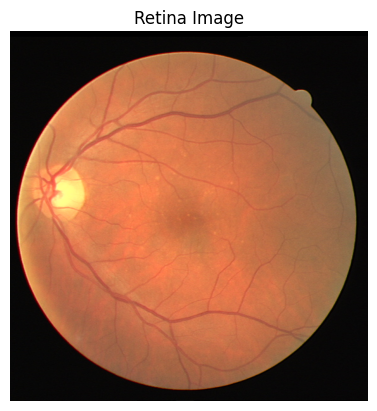

In [11]:
import cv2
import matplotlib.pyplot as plt

img_path = "data/raw/DRIVE/training/images/21_training.tif"

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis("off")
plt.title("Retina Image")
plt.show()


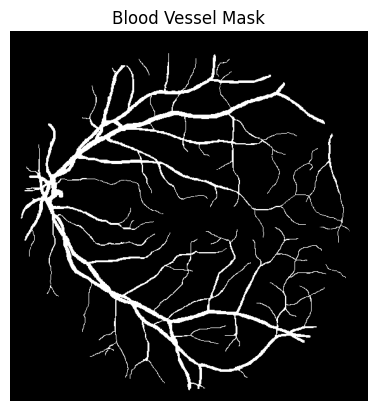

In [12]:
mask_path = "data/raw/DRIVE/training/1st_manual/21_manual1.gif"

mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

plt.imshow(mask, cmap="gray")
plt.axis("off")
plt.title("Blood Vessel Mask")
plt.show()


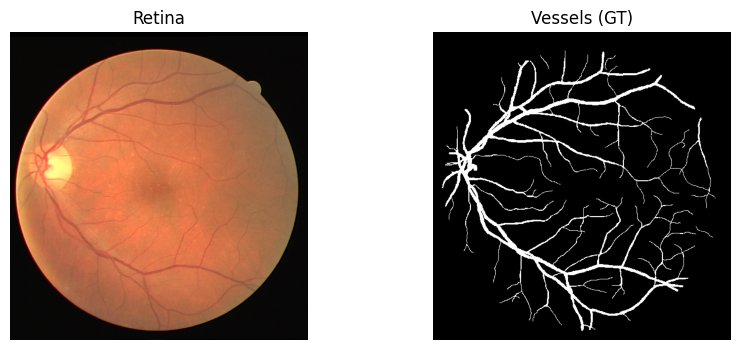

In [13]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Retina")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("Vessels (GT)")
plt.axis("off")

plt.show()


In [14]:
import os
import cv2
import torch
from torch.utils.data import Dataset

class RetinaDataset(Dataset):
    def __init__(self, image_dir, mask_dir, img_size=256):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.img_size = img_size
        
        self.images = sorted(os.listdir(image_dir))
        self.masks = sorted(os.listdir(mask_dir))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        # Load image
        img_path = os.path.join(self.image_dir, self.images[idx])
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (self.img_size, self.img_size))
        image = image / 255.0
        image = torch.tensor(image, dtype=torch.float32).permute(2, 0, 1)

        # Load mask
        mask_path = os.path.join(self.mask_dir, self.masks[idx])
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, (self.img_size, self.img_size))
        mask = mask / 255.0
        mask = torch.tensor(mask, dtype=torch.float32).unsqueeze(0)

        return image, mask


In [15]:
train_dataset = RetinaDataset(
    image_dir="data/raw/DRIVE/training/images",
    mask_dir="data/raw/DRIVE/training/1st_manual",
    img_size=256
)

print("Total training samples:", len(train_dataset))


Total training samples: 20


In [16]:
img, mask = train_dataset[0]

print("Image shape:", img.shape)
print("Mask shape:", mask.shape)


Image shape: torch.Size([3, 256, 256])
Mask shape: torch.Size([1, 256, 256])
